In [1]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import os, random

In [2]:
path = "/kaggle/input/handwritten-digits-0-9/"

if os.path.exists(path) == False:
  path = kagglehub.dataset_download("olafkrastovski/handwritten-digits-0-9")

print("Path to dataset files:", path)

100%|██████████| 66.7M/66.7M [00:00<00:00, 163MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/olafkrastovski/handwritten-digits-0-9/versions/2


In [3]:
pic_size = 128

training_dt = tf.keras.utils.image_dataset_from_directory(
    path,
    labels="inferred",
    label_mode="int",
    subset='training',
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
    validation_split=0.2,
)

validation_dt = tf.keras.utils.image_dataset_from_directory(
    path,
    labels="inferred",
    label_mode="int",
    subset='validation',
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
    validation_split=0.2,
)

Found 21555 files belonging to 10 classes.
Using 17244 files for training.
Found 21555 files belonging to 10 classes.
Using 4311 files for validation.


In [4]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(pic_size, pic_size, 3)),
    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),

    layers.Dense(112, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(112, activation="relu"),
    layers.Dense(10, activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.0001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
epoch = 5

def decay():
  if epoch < 3:
    return 1e-3
  elif epoch >= 3 and epoch < 7:
    return 1e-4
  else:
    return 1e-5

lr_decay = tf.keras.callbacks.LearningRateScheduler(decay)

history = model.fit(
    training_dt, validation_data=validation_dt, epochs=epoch, callbacks=[lr_decay]
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


539/539 ━━━━━━━━━━━━━━━━━━━━ 349s 642ms/step - accuracy: 0.2880 - loss: 2.0182 - val_accuracy: 0.5020 - val_loss: 1.5395
Epoch 2/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 373s 692ms/step - accuracy: 0.6417 - loss: 1.1435 - val_accuracy: 0.7175 - val_loss: 0.9014
Epoch 3/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 390s 707ms/step - accuracy: 0.7986 - loss: 0.6451 - val_accuracy: 0.8274 - val_loss: 0.5887
Epoch 4/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 385s 711ms/step - accuracy: 0.8671 - loss: 0.4382 - val_accuracy: 0.8559 - val_loss: 0.4705
Epoch 5/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 406s 645ms/step - accuracy: 0.8983 - loss: 0.3303 - val_accuracy: 0.8910 - val_loss: 0.3769


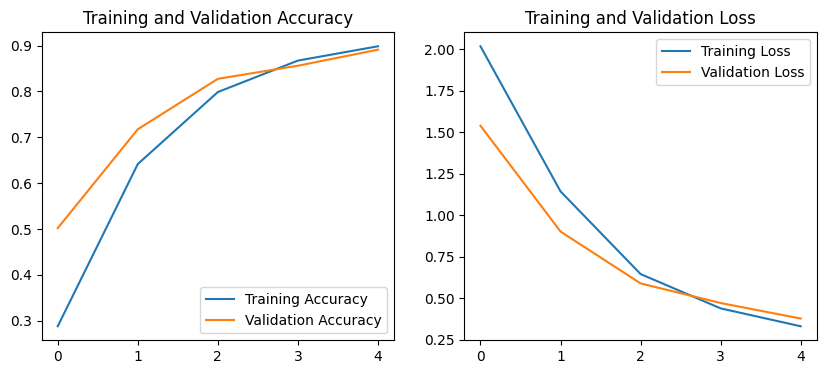

In [6]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epoch)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [11]:
class_names = training_dt.class_names
DATA_DIR = path
IMG_HEIGHT = pic_size
IMG_WIDTH = pic_size

Now that the model is saved, let's load it and make a prediction on a sample image that was not part of the training data.

In [15]:
model_path = 'european_digits_model.keras'
model.save(model_path)
print(f"Model successfully saved to: {model_path}")

Model successfully saved to: european_digits_model.keras


In [9]:
saved_model = tf.keras.models.load_model("/content/european_digits_model.keras")

saved_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 112)            │     1,835,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         7,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 112)            │         7,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,623,040 (21.45 MB)

 Trainable params: 1,874,346 (7.15 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,748,694 (14.30 MB)

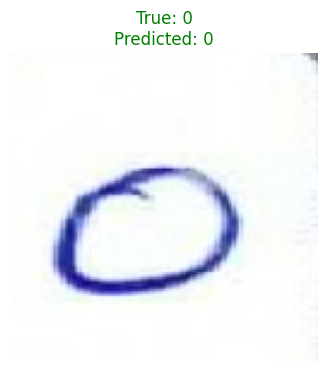

In [14]:
def load_and_preprocess_image(image_path, size=(128, 128)):
  img = tf.keras.utils.load_img(image_path, target_size=size)
  img_arr = tf.keras.utils.img_to_array(img)
  img_batch = tf.expand_dims(img_arr, 0)

  return img_batch, img_arr

Predicted Class Index: 7
Predicted Label: 7
True Label: 7


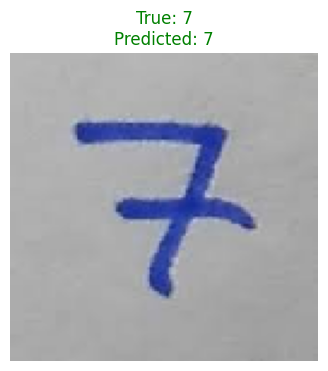

In [25]:
img_batch, img_display = load_and_preprocess_image("/content/seven1.jpeg", size=(pic_size, pic_size))

predictions = saved_model.predict(img_batch, verbose=0)
predicted_class_idx = np.argmax(predictions[0])
predicted_label = class_names[predicted_class_idx]

true_label = '7'

print(predictions)
print(f"Predicted Label: {predicted_label}")
print(f"True Label: {true_label}")

plt.figure(figsize=(4, 4))
plt.imshow(img_display.astype("uint8"))
color = 'green' if true_label == predicted_label else 'red'
plt.title(f"True: {true_label}\nPredicted: {predicted_label}", color=color)
plt.axis("off")
plt.show()